Titanic NN Model


In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
import pickle
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/titanic_prepared.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Newfare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,10.8750
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,142.5666
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,11.8875
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,106.2000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,12.0750


In [4]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Newfare        0
dtype: int64

In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
Newfare        float64
dtype: object

In [6]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Newfare"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [7]:
categorical_features = ["Sex", "Embarked"]


OneHot Encoder

In [8]:
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
one_hot_encoder.fit(df[categorical_features])
one_hot_encoder

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [9]:
Column_features = one_hot_encoder.get_feature_names_out(categorical_features)
Column_features

array(['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype=object)

In [10]:
transformed_categorical_features = one_hot_encoder.transform(df[categorical_features])
transformed_categorical_features

array([[0., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 0.],
       [0., 1., 0., 1., 0.]], shape=(881, 5))

Creating a Dataframe

In [11]:
df_transformed = pd.DataFrame(
    transformed_categorical_features, columns=Column_features)
df_transformed.head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


Replacing the Dataframe with the categorical features


In [12]:
df = df.drop(columns=categorical_features)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [13]:
final_df = df.join(df_transformed)
final_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0


In [14]:
final_df.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_female    float64
Sex_male      float64
Embarked_C    float64
Embarked_Q    float64
Embarked_S    float64
dtype: object

In [15]:
final_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,881.000000,881.000000,881.000000,881.000000,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,0.384790,2.316686,29.153995,0.527809,0.38479,32.136511,0.354143,0.645857,0.188422,0.086266,0.725312
std,0.486822,0.833015,14.022600,1.107602,0.80943,49.877961,0.478524,0.478524,0.391271,0.280915,0.446610
min,0.000000,1.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.00000,7.895800,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.00000,14.454200,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.00000,30.695800,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,3.000000,65.000000,8.000000,6.00000,512.329200,1.000000,1.000000,1.000000,1.000000,1.000000


MinMaxScaler

In [16]:
columns_to_scale = ["Age", "SibSp", "Parch", "Fare", "Pclass"]
scaler = MinMaxScaler(clip=True)
final_df[columns_to_scale] = scaler.fit_transform(final_df[columns_to_scale])
final_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,1.0,0.334159,0.125,0.0,0.014151,0.0,1.0,0.0,0.0,1.0
1,1,0.0,0.581914,0.125,0.0,0.139136,1.0,0.0,1.0,0.0,0.0
2,1,1.0,0.396098,0.000,0.0,0.015469,1.0,0.0,0.0,0.0,1.0
3,1,0.0,0.535460,0.125,0.0,0.103644,1.0,0.0,0.0,0.0,1.0
4,0,1.0,0.535460,0.000,0.0,0.015713,0.0,1.0,0.0,0.0,1.0


In [17]:
final_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,0.384790,0.658343,0.444936,0.065976,0.064132,0.062726,0.354143,0.645857,0.188422,0.086266,0.725312
std,0.486822,0.416508,0.217135,0.138450,0.134905,0.097355,0.478524,0.478524,0.391271,0.280915,0.446610
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.500000,0.303190,0.000000,0.000000,0.015412,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.427067,0.000000,0.000000,0.028213,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,0.581914,0.125000,0.000000,0.059914,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
scaler.transform([[80, 0, 0, 300, 1]])

c:\Users\monat\anaconda3\envs\ai\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[1.      , 0.      , 0.      , 0.585561, 0.      ]])

Pickle

In [19]:
#Saving an object to disk
#pickle.dump(scaler, open("../object/titanic_scaler.pkl", "wb"))

In [20]:
#Loading an object from disk
#scaler_loaded = pickle.load(open("../object/titanic_scaler.pkl", "rb"))

Train/Test NN Model

In [21]:
x = final_df.drop(columns=["Survived"])
y = final_df["Survived"]
y

0      0
1      1
2      1
3      1
4      0
      ..
876    0
877    1
878    0
879    1
880    0
Name: Survived, Length: 881, dtype: int64

In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [23]:
x_train.shape

(704, 10)

In [24]:
x_test.shape

(177, 10)

In [32]:
y_test.shape

(177,)

In [25]:
model = MLPClassifier(hidden_layer_sizes=(30,20,), solver='adam', max_iter=2000, random_state=42, 
                      verbose=True, early_stopping=True, n_iter_no_change=50)
model.fit(x_train, y_train)

Iteration 1, loss = 0.71919877
Validation score: 0.380282
Iteration 2, loss = 0.70115501
Validation score: 0.563380
Iteration 3, loss = 0.68506661
Validation score: 0.816901
Iteration 4, loss = 0.66902169
Validation score: 0.774648
Iteration 5, loss = 0.65385862
Validation score: 0.746479
Iteration 6, loss = 0.63882305
Validation score: 0.746479
Iteration 7, loss = 0.62286606
Validation score: 0.746479
Iteration 8, loss = 0.60793695
Validation score: 0.746479
Iteration 9, loss = 0.59321242
Validation score: 0.746479
Iteration 10, loss = 0.58055755
Validation score: 0.746479
Iteration 11, loss = 0.56874590
Validation score: 0.746479
Iteration 12, loss = 0.55908063
Validation score: 0.746479
Iteration 13, loss = 0.55022444
Validation score: 0.746479
Iteration 14, loss = 0.54227118
Validation score: 0.746479
Iteration 15, loss = 0.53521146
Validation score: 0.760563
Iteration 16, loss = 0.52859811
Validation score: 0.788732
Iteration 17, loss = 0.52199542
Validation score: 0.746479
Iterat

,hidden_layer_sizes,"(30, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


In [26]:
loss_curve = model.loss_curve_
loss_curve

[np.float64(0.7191987711168987),
 np.float64(0.7011550090408984),
 np.float64(0.6850666142301726),
 np.float64(0.6690216941986411),
 np.float64(0.6538586169306558),
 np.float64(0.6388230517473573),
 np.float64(0.6228660637112922),
 np.float64(0.6079369522825621),
 np.float64(0.5932124206074159),
 np.float64(0.5805575536340457),
 np.float64(0.568745902134515),
 np.float64(0.559080629407987),
 np.float64(0.5502244404656127),
 np.float64(0.542271176885298),
 np.float64(0.5352114638538985),
 np.float64(0.5285981142862428),
 np.float64(0.5219954238831518),
 np.float64(0.5165068489420684),
 np.float64(0.5119080355277486),
 np.float64(0.5068922432559642),
 np.float64(0.5028815491288012),
 np.float64(0.4994330875179124),
 np.float64(0.49618715344084025),
 np.float64(0.49289994913648205),
 np.float64(0.49004586908147235),
 np.float64(0.48745173263507446),
 np.float64(0.48499126616032745),
 np.float64(0.4828222574551834),
 np.float64(0.48063750003425937),
 np.float64(0.4789262384291681),
 np.flo

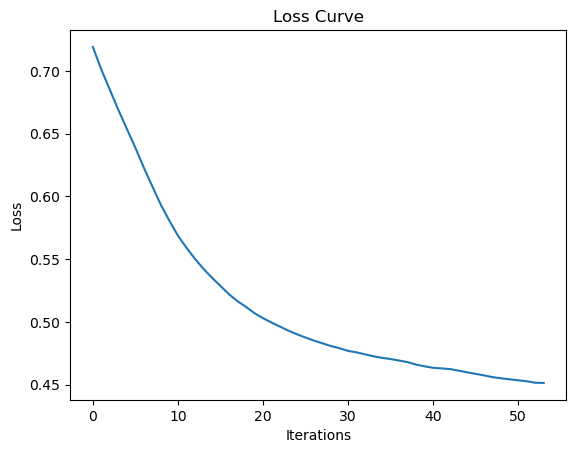

In [27]:
plt.plot(loss_curve)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve") 
plt.show()

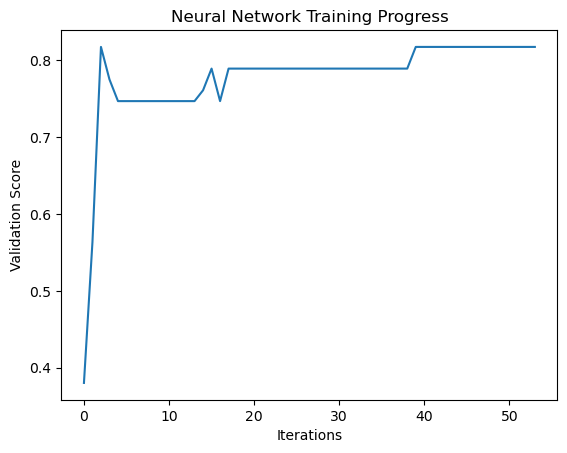

In [28]:
validation_score = model.validation_scores_
plt.plot(validation_score)
plt.xlabel("Iterations")
plt.ylabel("Validation Score")
plt.title("Neural Network Training Progress")
plt.show()

In [29]:
predictions = model.predict(x_test)
predictions

array([1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       0])

In [30]:
y_test.values

array([0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0])

Testing/Confusion Matrix

In [31]:
correct = 0
wrong = 0
for i in range(len(y_test)):
    if predictions[i] == y_test.values[i]:
        correct += 1
    else:
        wrong += 1

correct, wrong

(137, 40)

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [34]:
model.classes_

array([0, 1])

In [37]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
cm

array([[91, 13],
       [27, 46]])

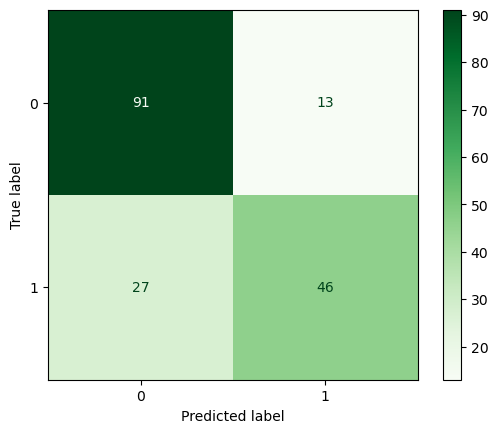

In [41]:
disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot(cmap="Greens")
plt.show()

In [42]:
from sklearn.metrics import f1_score

In [43]:
f1_score(y_test, predictions)

0.696969696969697

In [44]:
model.score(x_test, y_test)

0.7740112994350282

In [45]:
model.feature_names_in_

array(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'], dtype=object)

In [46]:
import pickle

In [47]:
with open("../object/titanic-model.pickle", "wb") as f:
    pickle.dump(model,f)

In [48]:
with open("../object/titanic-encoder.pickle", "wb") as f:
    pickle.dump(one_hot_encoder,f)